### Dataset Import etc

In [113]:
import sys

print("Python version:")
print(sys.version)

print("\nPython executable:")
print(sys.executable)

Python version:
3.12.3 (main, Aug 31 2026, 10:18:26) [GCC 13.3.0]

Python executable:
/home/administrator/Desktop/MVBC/Research_Work/06_Experiments/SNN/step_1_VIO/.venv/bin/python


In [114]:
import tonic

print("Tonic version:", tonic.__version__)
print("Tonic location:", tonic.__file__)

Tonic version: 1.6.0
Tonic location: /home/administrator/Desktop/MVBC/Research_Work/06_Experiments/SNN/step_1_VIO/.venv/lib/python3.12/site-packages/tonic/__init__.py


In [115]:
import tonic

print([
    name
    for name in dir(tonic.datasets)
    if "DAVIS" in name.upper()
])

['DAVISDATA', 'davisdataset']


In [116]:
help(tonic.datasets.DAVISDATA)

Help on class DAVISDATA in module tonic.datasets.davisdataset:

class DAVISDATA(tonic.dataset.Dataset)
 |  DAVISDATA(save_to: str, recording: Union[str, List[str]], transform: Optional[Callable] = None, target_transform: Optional[Callable] = None, transforms: Optional[Callable] = None)
 |
 |  `DAVIS event camera dataset <http://rpg.ifi.uzh.ch/davis_data.html>`_
 |  ::
 |
 |      @article{mueggler2017event,
 |        title={The event-camera dataset and simulator: Event-based data for pose estimation, visual odometry, and SLAM},
 |        author={Mueggler, Elias and Rebecq, Henri and Gallego, Guillermo and Delbruck, Tobi and Scaramuzza, Davide},
 |        journal={The International Journal of Robotics Research},
 |        volume={36},
 |        number={2},
 |        pages={142--149},
 |        year={2017},
 |        publisher={SAGE Publications Sage UK: London, England}
 |      }
 |
 |  Parameters:
 |      save_to (string): Location to save files to on disk. Will save files in a sub fold

### Loading of Dataset

In [117]:
import tonic

dataset = tonic.datasets.DAVISDATA(
    save_to="../data/DAVIS",
    recording="shapes_6dof"
)

print(dataset)
print("Number of samples:", len(dataset))

DAVISDATA
Number of samples: 1


In [118]:
data,target= dataset[0]


In [119]:
type(data), type(target)

(tuple, dict)

### dataset raw data items

In [120]:
print("Number of items in data:", len(data))

for i, item in enumerate(data):
    print(f"\ndata[{i}]")
    print("  type:", type(item))
    
    if isinstance(item, dict):
        print("  keys:", item.keys())
    else:
        print("  shape:", getattr(item, "shape", None))
        print("  dtype:", getattr(item, "dtype", None))

print("\nTarget")
print("  type:", type(target))
print("  keys:", target.keys())

Number of items in data: 3

data[0]
  type: <class 'numpy.ndarray'>
  shape: (17962477,)
  dtype: [('t', '<i8'), ('x', '<i8'), ('y', '<i8'), ('p', '<i8')]

data[1]
  type: <class 'dict'>
  keys: dict_keys(['ts', 'rotQ', 'angV', 'acc', 'mag', 'rosbagType'])

data[2]
  type: <class 'dict'>
  keys: dict_keys(['ts', 'frames', 'rosbagType'])

Target
  type: <class 'dict'>
  keys: dict_keys(['ts', 'point', 'rotation', 'rosbagType'])


### working on event camera data

In [121]:
events = data[0]
print("\nEvents")
print("  shape:", events.shape)
print("  dtype:", events.dtype)
for i in range(10):
    print(
        i,
        "t =", events[i]["t"],
        "x =", events[i]["x"],
        "y =", events[i]["y"],
        "p =", events[i]["p"]
    )


Events
  shape: (17962477,)
  dtype: [('t', '<i8'), ('x', '<i8'), ('y', '<i8'), ('p', '<i8')]
0 t = 0 x = 50 y = 40 p = 0
1 t = 494 x = 216 y = 14 p = 0
2 t = 648 x = 156 y = 51 p = 1
3 t = 669 x = 57 y = 114 p = 1
4 t = 705 x = 208 y = 91 p = 1
5 t = 705 x = 203 y = 72 p = 0
6 t = 1060 x = 169 y = 158 p = 1
7 t = 1199 x = 195 y = 83 p = 1
8 t = 1299 x = 210 y = 23 p = 1
9 t = 1412 x = 207 y = 91 p = 1


### span of events,event rate,image dimension

In [122]:
t = events["t"]
x =events["x"]
y = events["y"]
p = events["p"]
print("First timestamp:", t[0])
print("Last timestamp :", t[-1])
print("Duration:",t[-1] - t[0], "us")
duration_ms = (t[-1] - t[0]) / 1000
print("Duration:", duration_ms, "ms")
duration_s = duration_ms / 1000
print("Duration:", duration_s, "s")
average_event_rate = len(events) / duration_s
print("Average event rate:", average_event_rate, "Hz")
width = int(x.max()) + 1
height = int(y.max()) + 1

print("image width:", width, "height:", height)

First timestamp: 0
Last timestamp : 59735406
Duration: 59735406 us
Duration: 59735.406 ms
Duration: 59.735406000000005 s
Average event rate: 300700.6765803182 Hz
image width: 240 height: 180


In [123]:

import numpy as np
t_start = 0
t_end = 1000000       # 1000 μs = 1 ms

mask = (t >= t_start) & (t < t_end)
events_1ms = events[mask]
print("Events in first 1 ms:", len(events_1ms))
print(events_1ms[:])
for window_us in [1000, 5000, 10000, 50000, 100000, 500000, 1000000]:
    mask = (t >= 0) & (t < window_us)

    print(
        f"{window_us/1000:} ms : "
        f"{np.sum(mask):} events"
    )

Events in first 1 ms: 52362
[(     0,  50,  40, 0) (   494, 216,  14, 0) (   648, 156,  51, 1) ...
 (999987, 138, 152, 0) (999992,  27, 101, 0) (999994,  52,  48, 1)]
1.0 ms : 6 events
5.0 ms : 34 events
10.0 ms : 65 events
50.0 ms : 265 events
100.0 ms : 1561 events
500.0 ms : 12960 events
1000.0 ms : 52362 events


### DENSE Representation

### 1)Event Image representation

In [124]:
t_start = 0
t_end = 1000000 # 1000 μs = 1 ms

mask = (t >= t_start) & (t < t_end)
events_1ms = events[mask]
x_w = x[mask]
y_w = y[mask]
p_w = p[mask]
t_w = t[mask]
event_frame = np.zeros(
    (height, width),
    dtype=np.int32
)

for xi, yi in zip(x_w, y_w):
    event_frame[yi, xi] += 1

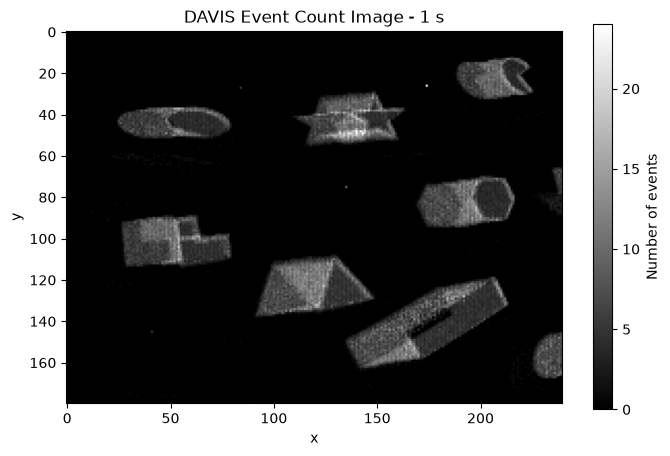

In [125]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.imshow(event_frame, cmap="gray", origin="upper")
plt.xlabel("x")
plt.ylabel("y")
plt.title("DAVIS Event Count Image - 1 s")
plt.colorbar(label="Number of events")
plt.show()

### 2)Polarity Image 

In [126]:
polarity_frame = np.zeros(
    (height, width),
    dtype=np.int32
)

for xi, yi, pi in zip(x_w, y_w, p_w):

    if pi == 1:
        polarity_frame[yi, xi] += 1
    else:
        polarity_frame[yi, xi] -= 1

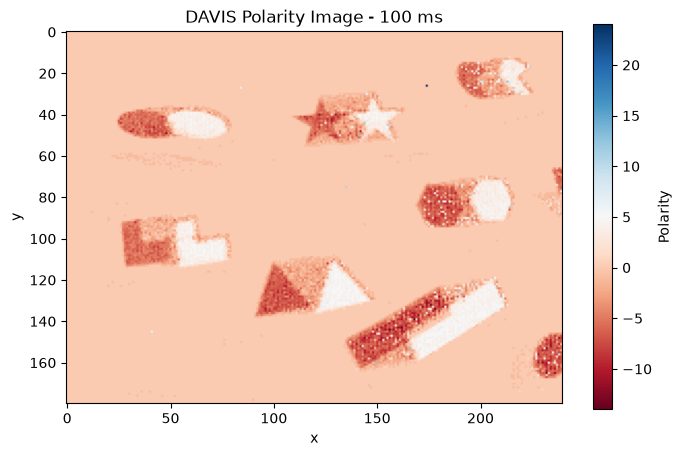

In [127]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.imshow(polarity_frame, cmap="RdBu", origin="upper")
plt.xlabel("x")
plt.ylabel("y")
plt.title("DAVIS Polarity Image - 100 ms")
plt.colorbar(label="Polarity")
plt.show()

### 3)Surface of Active Event (SAE)

In [128]:
import numpy as np
sae = np.zeros(
    (height, width),
    dtype=np.int64
)
#1 sae
for xi, yi, ti in zip(x_w, y_w, t_w):
    sae[yi, xi] = ti

sae_recency = np.zeros(
    (height, width),
    dtype=np.int64
)

valid = sae > 0
#2 sae_recency
sae_recency[valid] = t_end - sae[valid]

sae_vis = np.zeros(
    (height, width),
    dtype=np.float32
)

valid = sae > 0
#3 sae_vis
sae_vis[valid] = (
    sae[valid] - t_start
) / (t_end - t_start)

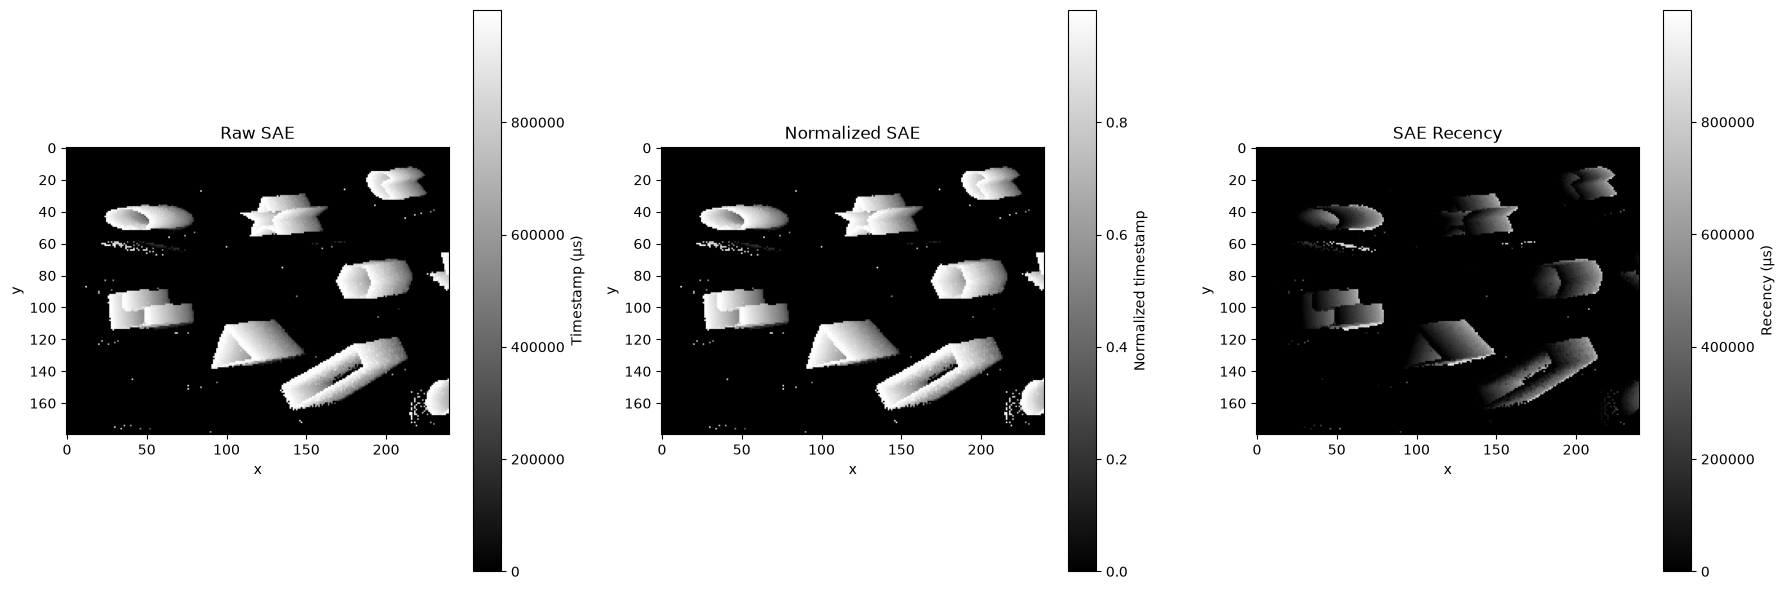

In [129]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Raw SAE
im1 = axes[0].imshow(
    sae,
    cmap="gray",
    origin="upper"
)
axes[0].set_title("Raw SAE")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
fig.colorbar(im1, ax=axes[0], label="Timestamp (μs)")

# 2. Normalized SAE
im2 = axes[1].imshow(
    sae_vis,
    cmap="gray",
    origin="upper"
)
axes[1].set_title("Normalized SAE")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
fig.colorbar(im2, ax=axes[1], label="Normalized timestamp")

# 3. SAE Recency
im3 = axes[2].imshow(
    sae_recency,
    cmap="gray",
    origin="upper"
)
axes[2].set_title("SAE Recency")
axes[2].set_xlabel("x")
axes[2].set_ylabel("y")
fig.colorbar(im3, ax=axes[2], label="Recency (μs)")

plt.tight_layout()
plt.show()

### 4) Time Surface representation

In [130]:
import numpy as np
import matplotlib.pyplot as plt

t_current = t_end
tau = 200000       # 200 μs

time_surface = np.zeros(
    (height, width),
    dtype=np.int64
)

for xi, yi, ti in zip(x_w, y_w, t_w):
    time_surface[yi, xi] = ti

# Exponential time surface
ts_exp = np.zeros(
    (height, width),
    dtype=np.float32
)

valid = time_surface > 0

ts_exp[valid] = np.exp(
    -(t_current - time_surface[valid]) / tau
)

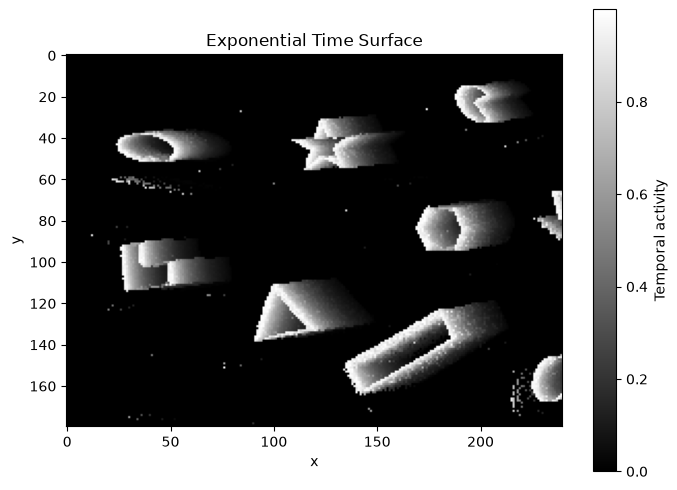

In [131]:
plt.figure(figsize=(8, 6))

plt.imshow(
    ts_exp,
    cmap="gray",
    origin="upper"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Exponential Time Surface")
plt.colorbar(label="Temporal activity")

plt.show()

### 5)Voxel Grid Representation

In [132]:
t_start = 0
t_end = 1000000 # 1 ms = 1,000,000 μs

mask = (t >= t_start) & (t < t_end)

events_1ms = events[mask]

x_w = x[mask]
y_w = y[mask]
p_w = p[mask]
t_w = t[mask]
num_bins = 10

voxel_grid = np.zeros(
    (num_bins, height, width),
    dtype=np.float32
)

bin_idx = int(
    (ti - t_start) /
    (t_end - t_start) *
    num_bins
)

for xi, yi, pi, ti in zip(x_w, y_w, p_w, t_w):

    bin_idx = int(
        (ti - t_start) /
        (t_end - t_start) *
        num_bins
    )

    
    if bin_idx >= num_bins:
        bin_idx = num_bins - 1

    polarity = 1 if pi == 1 else -1

    voxel_grid[bin_idx, yi, xi] += polarity

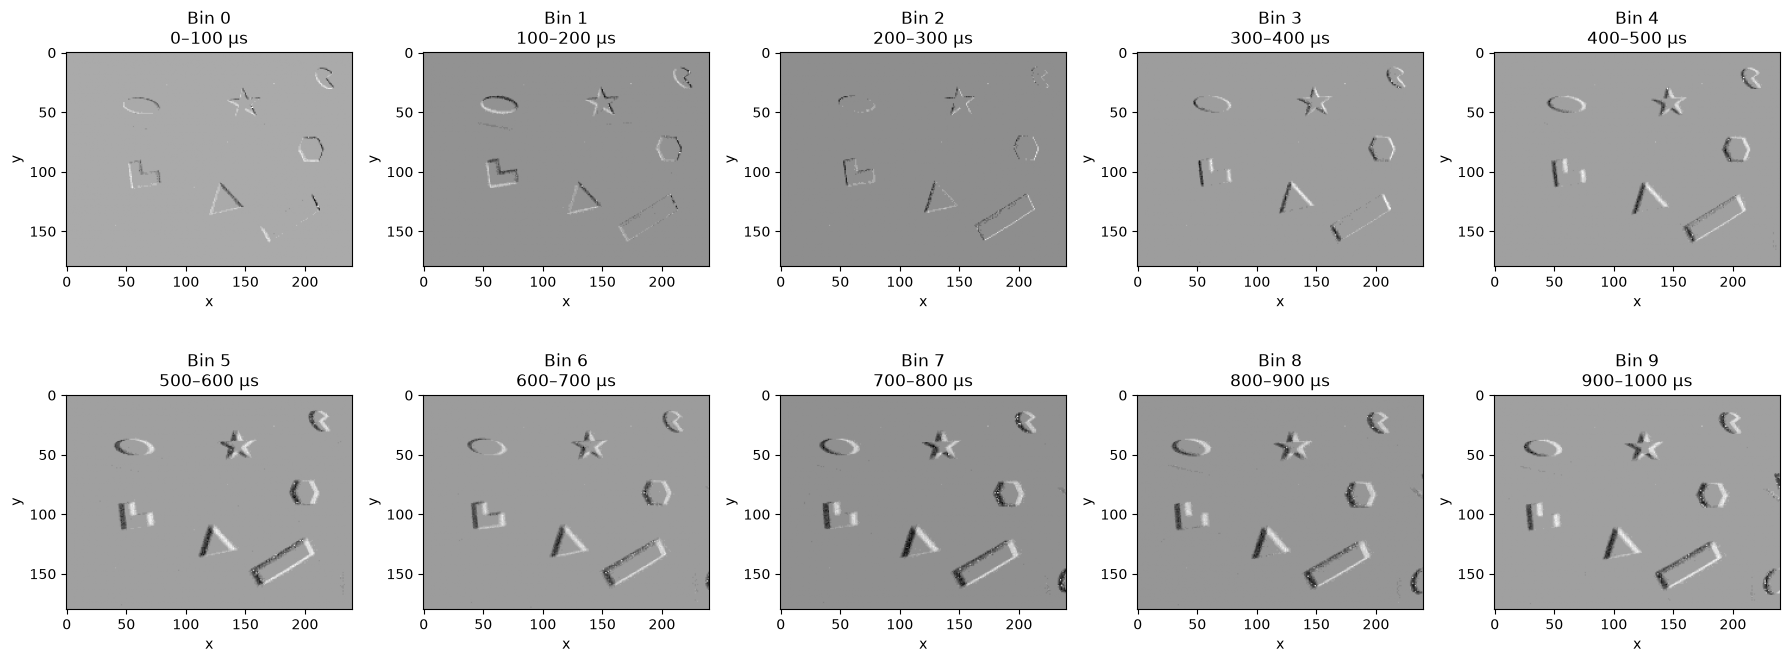

In [133]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    2, 5,
    figsize=(18, 7)
)

for b, ax in enumerate(axes.flat):

    im = ax.imshow(
        voxel_grid[b],
        cmap="gray",
        origin="upper"
    )

    ax.set_title(
        f"Bin {b}\n"
        f"{b * 100}–{(b + 1) * 100} μs"
    )

    ax.set_xlabel("x")
    ax.set_ylabel("y")

plt.tight_layout()
plt.show()

### Sparse Representation

### Token based Representation

In [134]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree



t = events["t"]
x = events["x"]
y = events["y"]
p = events["p"]



window_us = 1000000 

t_start = t[0]
t_end = t_start + window_us

mask = (t >= t_start) & (t < t_end)

window_events = events[mask]

print("\nCommon time window")
print("------------------")
print("Start:", t_start)
print("End  :", t_end)
print("Duration:", window_us, "us")
print("Number of events:", len(window_events))


Common time window
------------------
Start: 0
End  : 1000000
Duration: 1000000 us
Number of events: 52362


In [135]:


spatial_size = 16       # 16 x 16 pixel tile
temporal_size_us = 1000 # 1 ms

H = 180
W = 240

# Coordinates relative to beginning of window
t_rel = window_events["t"] - t_start

token_x = window_events["x"] // spatial_size
token_y = window_events["y"] // spatial_size
token_t = t_rel // temporal_size_us

token_p = window_events["p"]

# Unique spatial-temporal tokens
tokens, inverse = np.unique(
    np.column_stack([
        token_x,
        token_y,
        token_t
    ]),
    axis=0,
    return_inverse=True
)

print("Token representation")
print("Number of tokens:", len(tokens))
print("\nFirst tokens:")
print(tokens[:10])

Token representation
Number of tokens: 21955

First tokens:
[[  0   5 985]
 [  1   2 828]
 [  1   2 832]
 [  1   2 836]
 [  1   2 839]
 [  1   2 842]
 [  1   2 844]
 [  1   2 846]
 [  1   2 847]
 [  1   2 848]]


In [136]:
num_tokens = len(tokens)

token_count = np.bincount(
    inverse,
    minlength=num_tokens
)

token_polarity = np.bincount(
    inverse,
    weights=np.where(token_p == 1, 1, -1),
    minlength=num_tokens
)

token_mean_time = (
    np.bincount(
        inverse,
        weights=t_rel
    ) / np.maximum(token_count, 1)
)

token_features = np.column_stack([
    tokens,
    token_count,
    token_polarity,
    token_mean_time
])

print("\nToken feature format:")
print(
    "[x_tile, y_tile, time_bin, "
    "event_count, polarity_sum, mean_time]"
)

print(token_features[:10])


Token feature format:
[x_tile, y_tile, time_bin, event_count, polarity_sum, mean_time]
[[ 0.00000000e+00  5.00000000e+00  9.85000000e+02  1.00000000e+00
  -1.00000000e+00  9.85999000e+05]
 [ 1.00000000e+00  2.00000000e+00  8.28000000e+02  1.00000000e+00
  -1.00000000e+00  8.28444000e+05]
 [ 1.00000000e+00  2.00000000e+00  8.32000000e+02  1.00000000e+00
  -1.00000000e+00  8.32519000e+05]
 [ 1.00000000e+00  2.00000000e+00  8.36000000e+02  3.00000000e+00
  -3.00000000e+00  8.36495667e+05]
 [ 1.00000000e+00  2.00000000e+00  8.39000000e+02  1.00000000e+00
  -1.00000000e+00  8.39224000e+05]
 [ 1.00000000e+00  2.00000000e+00  8.42000000e+02  2.00000000e+00
  -2.00000000e+00  8.42668000e+05]
 [ 1.00000000e+00  2.00000000e+00  8.44000000e+02  1.00000000e+00
  -1.00000000e+00  8.44267000e+05]
 [ 1.00000000e+00  2.00000000e+00  8.46000000e+02  1.00000000e+00
  -1.00000000e+00  8.46760000e+05]
 [ 1.00000000e+00  2.00000000e+00  8.47000000e+02  1.00000000e+00
  -1.00000000e+00  8.47910000e+05]
 [ 

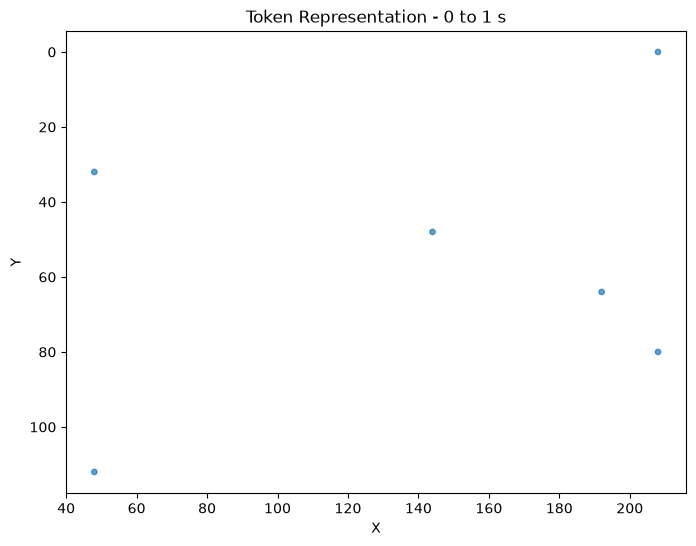

In [137]:
time_bin_to_show = 0

selected = tokens[:, 2] == time_bin_to_show

plt.figure(figsize=(8, 6))

plt.scatter(
    tokens[selected, 0] * spatial_size,
    tokens[selected, 1] * spatial_size,
    s=token_count[selected] * 5 + 10,
    alpha=0.7
)

plt.gca().invert_yaxis()

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Token Representation - 0 to 1 s")

plt.show()

### Graph Based Representation

In [138]:
graph_events = window_events

gx = graph_events["x"].astype(float)
gy = graph_events["y"].astype(float)
gt = graph_events["t"].astype(float)
gp = graph_events["p"]

num_nodes = len(graph_events)

print("Graph nodes:", num_nodes)
spatial_radius = 8
temporal_radius_us = 500

Graph nodes: 52362


In [139]:
coords = np.column_stack([
    gx,
    gy
])

tree = cKDTree(coords)

candidate_neighbors = tree.query_ball_point(
    coords,
    r=spatial_radius
)

In [140]:
edges = []

for i, neighbors in enumerate(candidate_neighbors):

    for j in neighbors:

        # Avoid self-loop
        if i == j:
            continue

        # Only connect to later events
        if j <= i:
            continue

        # Temporal constraint
        if abs(gt[i] - gt[j]) <= temporal_radius_us:

            edges.append([
                i,
                j
            ])

edges = np.asarray(edges, dtype=np.int64)

print("Graph representation")
print("Nodes:", num_nodes)
print("Edges:", len(edges))

Graph representation
Nodes: 52362
Edges: 69334


In [141]:
src = edges[:, 0]
dst = edges[:, 1]

dx = gx[dst] - gx[src]
dy = gy[dst] - gy[src]
dt = gt[dst] - gt[src]
dp = gp[dst] - gp[src]

edge_features = np.column_stack([
    dx,
    dy,
    dt,
    dp
])

print("Edge feature shape:", edge_features.shape)

print("\nFirst 10 edges:")
print(edges[:10])

print("\nFirst 10 edge features:")
print(edge_features[:10])

Edge feature shape: (69334, 4)

First 10 edges:
[[11 13]
 [13 15]
 [15 16]
 [20 23]
 [21 23]
 [45 46]
 [50 52]
 [55 59]
 [58 60]
 [66 67]]

First 10 edge features:
[[ -5.  -4. 435.  -1.]
 [  1.   2. 371.   1.]
 [ -2.  -1. 224.   0.]
 [ -3.   2. 387.   0.]
 [  7.   0. 337.   0.]
 [  3.  -2. 409.   0.]
 [  4.  -3.  66.   0.]
 [ -5.   1. 455.   0.]
 [ -1.   0. 333.   0.]
 [  6.   4.  21.   0.]]


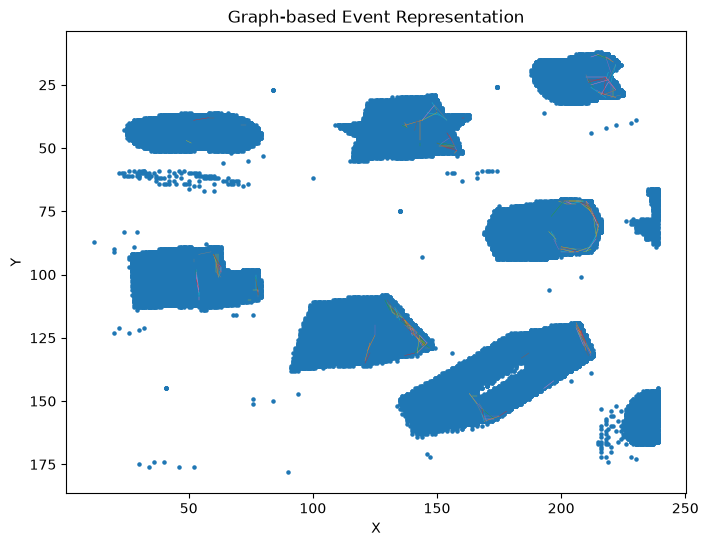

In [142]:
plt.figure(figsize=(8, 6))

# Plot nodes
plt.scatter(
    gx,
    gy,
    s=5
)

# Draw first 300 edges
for i, j in edges[:300]:

    plt.plot(
        [gx[i], gx[j]],
        [gy[i], gy[j]],
        linewidth=0.3
    )

plt.gca().invert_yaxis()

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Graph-based Event Representation")

plt.show()

### Point Based Representation

In [143]:

point_events = window_events

x_point = point_events["x"]
y_point = point_events["y"]
t_point = point_events["t"]
p_point = point_events["p"]

print("Point representation")

print("Shape:", point_events.shape)

print(point_events[:10])

Point representation
Shape: (52362,)
[(   0,  50,  40, 0) ( 494, 216,  14, 0) ( 648, 156,  51, 1)
 ( 669,  57, 114, 1) ( 705, 208,  91, 1) ( 705, 203,  72, 0)
 (1060, 169, 158, 1) (1199, 195,  83, 1) (1299, 210,  23, 1)
 (1412, 207,  91, 1)]


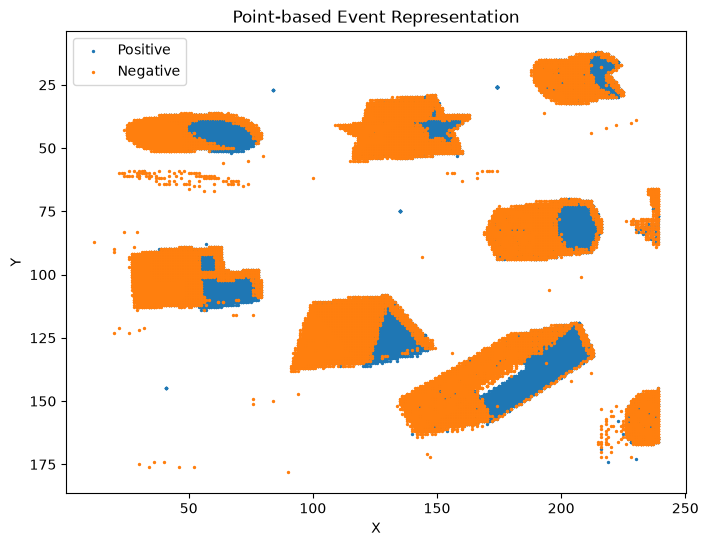

In [145]:
plt.figure(figsize=(8, 6))

positive = p_point == 1
negative = p_point == 0

plt.scatter(
    x_point[positive],
    y_point[positive],
    s=2,
    label="Positive"
)

plt.scatter(
    x_point[negative],
    y_point[negative],
    s=2,
    label="Negative"
)

plt.gca().invert_yaxis()

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Point-based Event Representation")
plt.legend()
plt.show()